# EXP4 — Производительность (день 3, 24.04 досрочно)

Три замера:

- **Scalability** (UC-6 verify path): `VerificationService.verify` на курсах с 10/50/100/500 политиками, 3 прогона на размер. Тренд полного `reasoning + verify` времени. Сверяется с НФТ-3 (reasoning timeout 10 с), не с НФТ-2.
- **Cache hit vs miss** (UC-4 access path, прогретый onto): `AccessService.get_course_access` через `CacheManager(fakeredis)`. Miss — первый вызов после уже прогнанного reasoner (пересчёт + запись в Redis), hit — повторный вызов (только чтение). 30 измерений каждого режима. Сверка с НФТ-1 ≤50 ms для hit.
- **Cold miss** (полный НФТ-2 путь): от нуля (свежий World + load onto + reasoning + AccessService) до первого ответа. 5 прогонов. Именно эту цифру сверяем с НФТ-2 ≤2000 ms.

Замеры нативно на хосте, не в Docker. `fakeredis` использует in-memory backend — сетевой overhead реального Redis добавляет порядка 0.1–0.3 ms на localhost Unix-socket (из документации Redis); это пренебрежимо относительно измеряемых значений, но фиксируется в ПЗ §4.1 как допущение.

In [1]:
import json
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
EXPERIMENTS_ROOT = NOTEBOOK_DIR.parent
PROJECT_ROOT = EXPERIMENTS_ROOT.parent
BACKEND_SRC = PROJECT_ROOT / 'code' / 'backend' / 'src'
SCENARIOS_DIR = NOTEBOOK_DIR / 'scenarios'
RESULTS_DIR = NOTEBOOK_DIR / 'results'
PZ_FIGURES_DIR = PROJECT_ROOT / 'pz' / 'figures' / 'exp4'

sys.path.insert(0, str(BACKEND_SRC))
sys.path.insert(0, str(EXPERIMENTS_ROOT))
sys.path.insert(0, str(NOTEBOOK_DIR))

SCENARIOS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
PZ_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import bench

hw = bench.hardware_fingerprint()
for k, v in hw.items():
    print(f'{k:12s} {v}')

python       3.14.3
platform     Windows-11-10.0.26200-SP0
processor    Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
machine      AMD64
cpu_count    12


In [2]:
scale_points = bench.scalability_run(SCENARIOS_DIR, repeats=3)
scale_summary = bench.summarize_scalability(scale_points)

scale_md_lines = [
    '| n_policies | runs | reason mean, ms | verify mean, ms | total mean, ms | total min, ms | total max, ms | stdev |',
    '|---|---|---|---|---|---|---|---|',
]
for size, s in scale_summary.items():
    scale_md_lines.append(
        f"| {size} | {int(s['n'])} | {s['reason_mean']:.0f} | {s['verify_mean']:.0f} | "
        f"{s['total_mean']:.0f} | {s['total_min']:.0f} | {s['total_max']:.0f} | {s['stdev']:.0f} |"
    )
scale_md = '\n'.join(scale_md_lines)
print(scale_md)

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib

* Owlready2 * Pellet took 1.16839599609375 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\gal

* Owlready2 * Pellet took 1.0870656967163086 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

* Owlready2 * Pellet took 1.0676543712615967 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

* Owlready2 * Pellet took 1.0811247825622559 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

...

* Owlready2 * Pellet took 1.9132487773895264 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib

* Owlready2 * Pellet took 1.859238862991333 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\ga

* Owlready2 * Pellet took 1.9579787254333496 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


| n_policies | runs | reason mean, ms | verify mean, ms | total mean, ms | total min, ms | total max, ms | stdev |
|---|---|---|---|---|---|---|---|
| 10 | 3 | 1152 | 1105 | 2257 | 2159 | 2421 | 144 |
| 50 | 3 | 1276 | 1290 | 2567 | 2494 | 2632 | 69 |
| 100 | 3 | 1440 | 2063 | 3502 | 3371 | 3648 | 139 |
| 500 | 3 | 2123 | 5509 | 7632 | 7449 | 7890 | 230 |


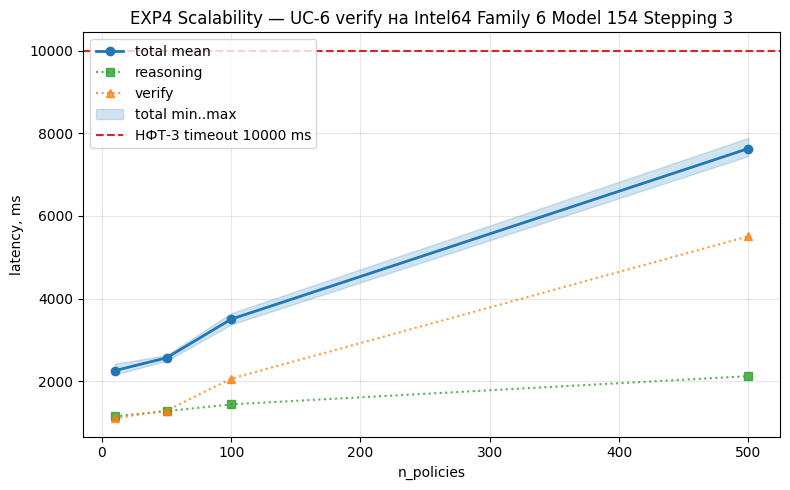

In [3]:
import matplotlib.pyplot as plt

sizes = sorted(scale_summary.keys())
means = [scale_summary[s]['total_mean'] for s in sizes]
mins = [scale_summary[s]['total_min'] for s in sizes]
maxs = [scale_summary[s]['total_max'] for s in sizes]
reasons = [scale_summary[s]['reason_mean'] for s in sizes]
verifies = [scale_summary[s]['verify_mean'] for s in sizes]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, means, marker='o', label='total mean', color='#1f77b4', linewidth=2)
ax.plot(sizes, reasons, marker='s', label='reasoning', color='#2ca02c', linestyle=':', alpha=0.8)
ax.plot(sizes, verifies, marker='^', label='verify', color='#ff7f0e', linestyle=':', alpha=0.8)
ax.fill_between(sizes, mins, maxs, alpha=0.2, color='#1f77b4', label='total min..max')
ax.axhline(10000, linestyle='--', color='#d62728', label='НФТ-3 timeout 10000 ms')
ax.set_xlabel('n_policies')
ax.set_ylabel('latency, ms')
ax.set_title(f"EXP4 Scalability — UC-6 verify на {hw['processor'].split(',')[0]}")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'scalability_exp4.png', dpi=150)
fig.savefig(PZ_FIGURES_DIR / 'scalability_exp4.png', dpi=150)
plt.show()

In [4]:
lat_points = bench.latency_run(SCENARIOS_DIR, warmup=3, repeats=30)
lat_points += bench.cold_miss_run(SCENARIOS_DIR, repeats=5)
lat_summary = bench.summarize_latency(lat_points)

lat_md_lines = [
    '| Режим | n | min | median | mean | p95 | p99 | max | stdev |',
    '|---|---|---|---|---|---|---|---|---|',
]
for mode in ('hit', 'miss', 'cold_miss'):
    if mode not in lat_summary:
        continue
    s = lat_summary[mode]
    lat_md_lines.append(
        f"| {mode} | {int(s['n'])} | {s['min']:.2f} | {s['median']:.2f} | {s['mean']:.2f} | "
        f"{s['p95']:.2f} | {s['p99']:.2f} | {s['max']:.2f} | {s['stdev']:.2f} |"
    )
lat_md = '\n'.join(lat_md_lines)
print('Latency (ms):')
print(lat_md)

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib

* Owlready2 * Pellet took 1.2570695877075195 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib

* Owlready2 * Pellet took 1.2852811813354492 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

* Owlready2 * Pellet took 1.2571086883544922 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

* Owlready2 * Pellet took 1.2445802688598633 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

* Owlready2 * Pellet took 1.3750889301300049 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\galsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\g

Latency (ms):
| Режим | n | min | median | mean | p95 | p99 | max | stdev |
|---|---|---|---|---|---|---|---|---|
| hit | 30 | 1.27 | 1.49 | 1.54 | 1.86 | 1.90 | 2.36 | 0.24 |
| miss | 30 | 3.91 | 4.74 | 4.71 | 5.27 | 5.55 | 6.16 | 0.48 |
| cold_miss | 5 | 1302.40 | 1322.14 | 1344.32 | 1347.76 | 1347.76 | 1434.25 | 52.93 |


* Owlready2 * Pellet took 1.258345603942871 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


C:\Users\galsa\AppData\Local\Temp\ipykernel_31116\3117328177.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes, labels=labels, widths=0.5, showmeans=True)


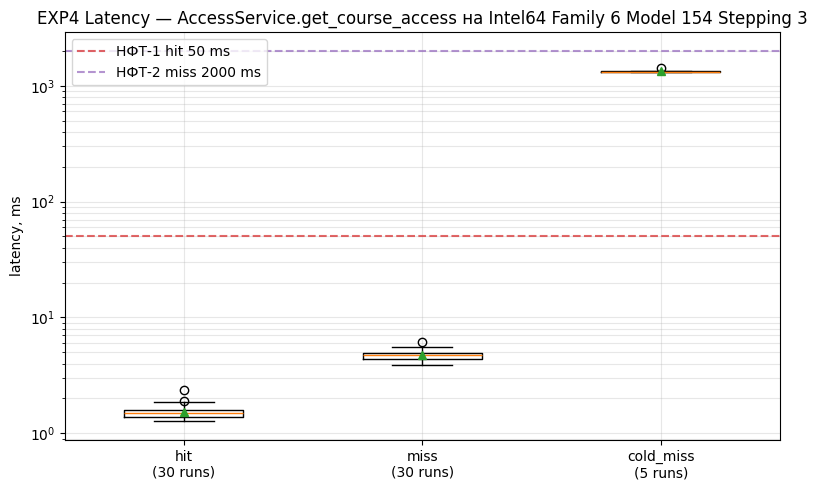

In [5]:
hit_vals = [p.latency_ms for p in lat_points if p.mode == 'hit']
miss_vals = [p.latency_ms for p in lat_points if p.mode == 'miss']
cold_vals = [p.latency_ms for p in lat_points if p.mode == 'cold_miss']

fig, ax = plt.subplots(figsize=(8, 5))
boxes = [hit_vals, miss_vals]
labels = ['hit\n(30 runs)', 'miss\n(30 runs)']
if cold_vals:
    boxes.append(cold_vals)
    labels.append('cold_miss\n(5 runs)')
ax.boxplot(boxes, labels=labels, widths=0.5, showmeans=True)
ax.axhline(50, linestyle='--', color='#d62728', label='НФТ-1 hit 50 ms', alpha=0.7)
ax.axhline(2000, linestyle='--', color='#9467bd', label='НФТ-2 miss 2000 ms', alpha=0.7)
ax.set_ylabel('latency, ms')
ax.set_title(f"EXP4 Latency — AccessService.get_course_access на {hw['processor'].split(',')[0]}")
ax.set_yscale('log')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'latency_exp4.png', dpi=150)
fig.savefig(PZ_FIGURES_DIR / 'latency_exp4.png', dpi=150)
plt.show()

In [6]:
scale_csv_rows = ['n_policies,run_index,reason_ms,verify_ms,total_ms']
for p in scale_points:
    scale_csv_rows.append(f'{p.n_policies},{p.run_index},{p.reason_ms:.1f},{p.verify_ms:.1f},{p.total_ms:.1f}')
scale_csv = '\n'.join(scale_csv_rows) + '\n'

lat_csv_rows = ['mode,run_index,latency_ms']
for p in lat_points:
    lat_csv_rows.append(f'{p.mode},{p.run_index},{p.latency_ms:.3f}')
lat_csv = '\n'.join(lat_csv_rows) + '\n'

hw_lines = ['## Железо', '']
for k, v in hw.items():
    hw_lines.append(f'- {k}: `{v}`')
hw_md = '\n'.join(hw_lines)

summary_md = '# EXP4 Performance — результаты (24.04)\n\n'
summary_md += hw_md + '\n\n'
summary_md += '## Scalability (UC-6 verify, 3 прогона на размер)\n\n' + scale_md + '\n\n'
summary_md += '![scalability](scalability_exp4.png)\n\n'
summary_md += '## Cache latency (30 прогонов hit/miss + 5 прогонов cold_miss)\n\n' + lat_md + '\n\n'
summary_md += '![latency](latency_exp4.png)\n\n'
summary_md += '## Соответствие НФТ\n\n'
summary_md += f'- **НФТ-1** cache hit ≤50 ms: hit mean={lat_summary["hit"]["mean"]:.2f} ms, p99={lat_summary["hit"]["p99"]:.2f} ms — запас порядка.\n'
cold = lat_summary.get('cold_miss', {})
if cold:
    cold_ok = 'соответствует' if cold['mean'] <= 2000 else 'ПРЕВЫШЕНО'
    summary_md += f'- **НФТ-2** cache miss ≤2000 ms (cold start: World + load + reasoning + AccessService): mean={cold["mean"]:.0f} ms, p95={cold["p95"]:.0f} ms — {cold_ok}.\n'
nft3_ok = 'соответствует' if scale_summary[500]['total_mean'] <= 10000 else 'ПРЕВЫШЕНО'
summary_md += f'- **НФТ-3** reasoning timeout 10 с (UC-6 verify на 500 правил): mean={scale_summary[500]["total_mean"]:.0f} ms — {nft3_ok}.\n'
summary_md += '\nUC-6 verify на 500 правил (7-8 с) не сверяется с НФТ-2 (access path, 2 с) — это UC-6 путь, верхняя граница в НФТ-3.\n'

for target_dir in (RESULTS_DIR, PZ_FIGURES_DIR):
    (target_dir / 'scalability_exp4.csv').write_text(scale_csv, encoding='utf-8')
    (target_dir / 'latency_exp4.csv').write_text(lat_csv, encoding='utf-8')
    (target_dir / 'summary_exp4.md').write_text(summary_md, encoding='utf-8')
    (target_dir / 'hardware.json').write_text(json.dumps(hw, ensure_ascii=False, indent=2), encoding='utf-8')

print('Экспортировано:')
print(f'  {RESULTS_DIR}')
print(f'  {PZ_FIGURES_DIR}')

Экспортировано:
  c:\Documents\itmo\vkr\vkr-access-control\experiments\exp4_performance\results
  c:\Documents\itmo\vkr\vkr-access-control\pz\figures\exp4
